In [7]:
import seaborn as sns

# Load the built-in titanic dataset
df = sns.load_dataset('Titanic')

# Display the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Da fare

- ripulire il dataset
- convertire categorie in numeri
- rimuovere outlier con z-score 3
- feature engineering
- normalizzare
- applicare logistic regression

In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Conta dei valori mancanti per colonna
print(df.isnull().sum() / len(df) * 100)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [10]:
# 1Elimina la colonna 'deck'
df = df.drop(columns=['deck'])

# 2Riempi i valori nulli della colonna 'age' con la mediana
df['age'] = df['age'].fillna(df['age'].mean())

# 3Elimina le righe dove 'embarked' è nullo
df = df.dropna(subset=['embarked'])

# Controllo finale dei valori nulli
print(df.isnull().sum())

# Mostra le prime righe pulite
print(df.head())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True 

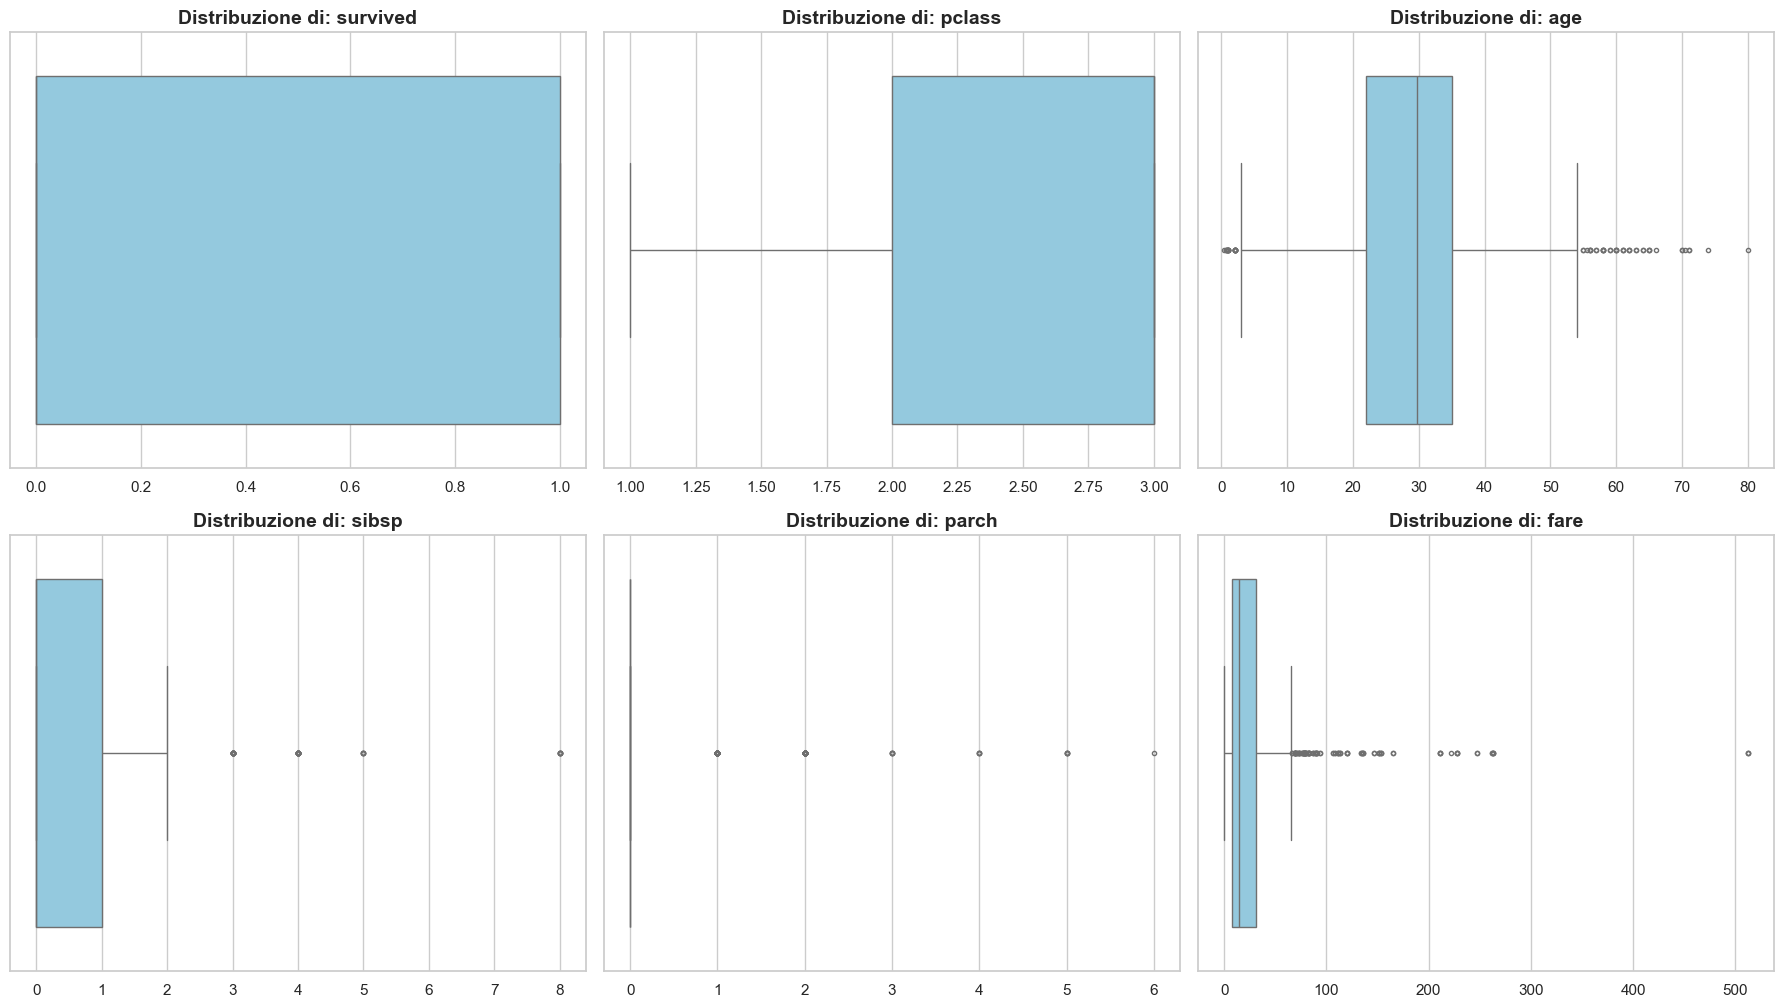

In [11]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione

df = remove_outliers_zscore(df, ['fare', 'parch', 'sibsp']) # age
#print(f"Righe rimosse con Z-Score: {len(df) - len(df)}")



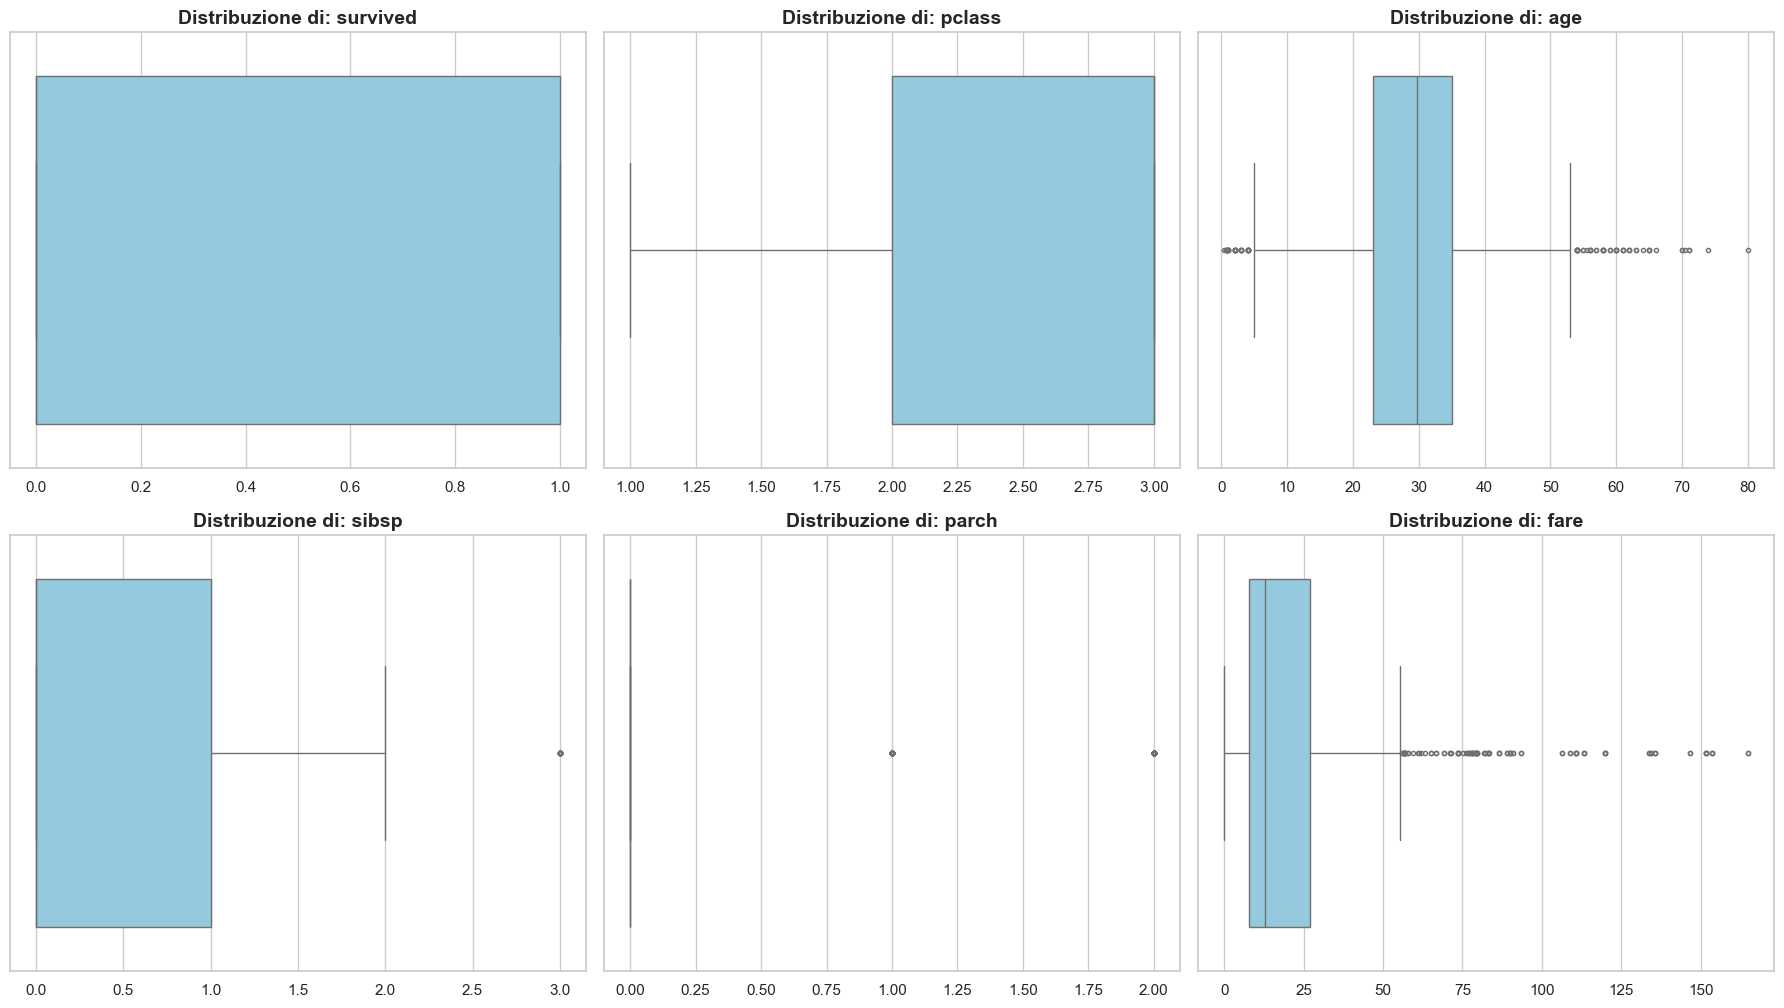

In [13]:
sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

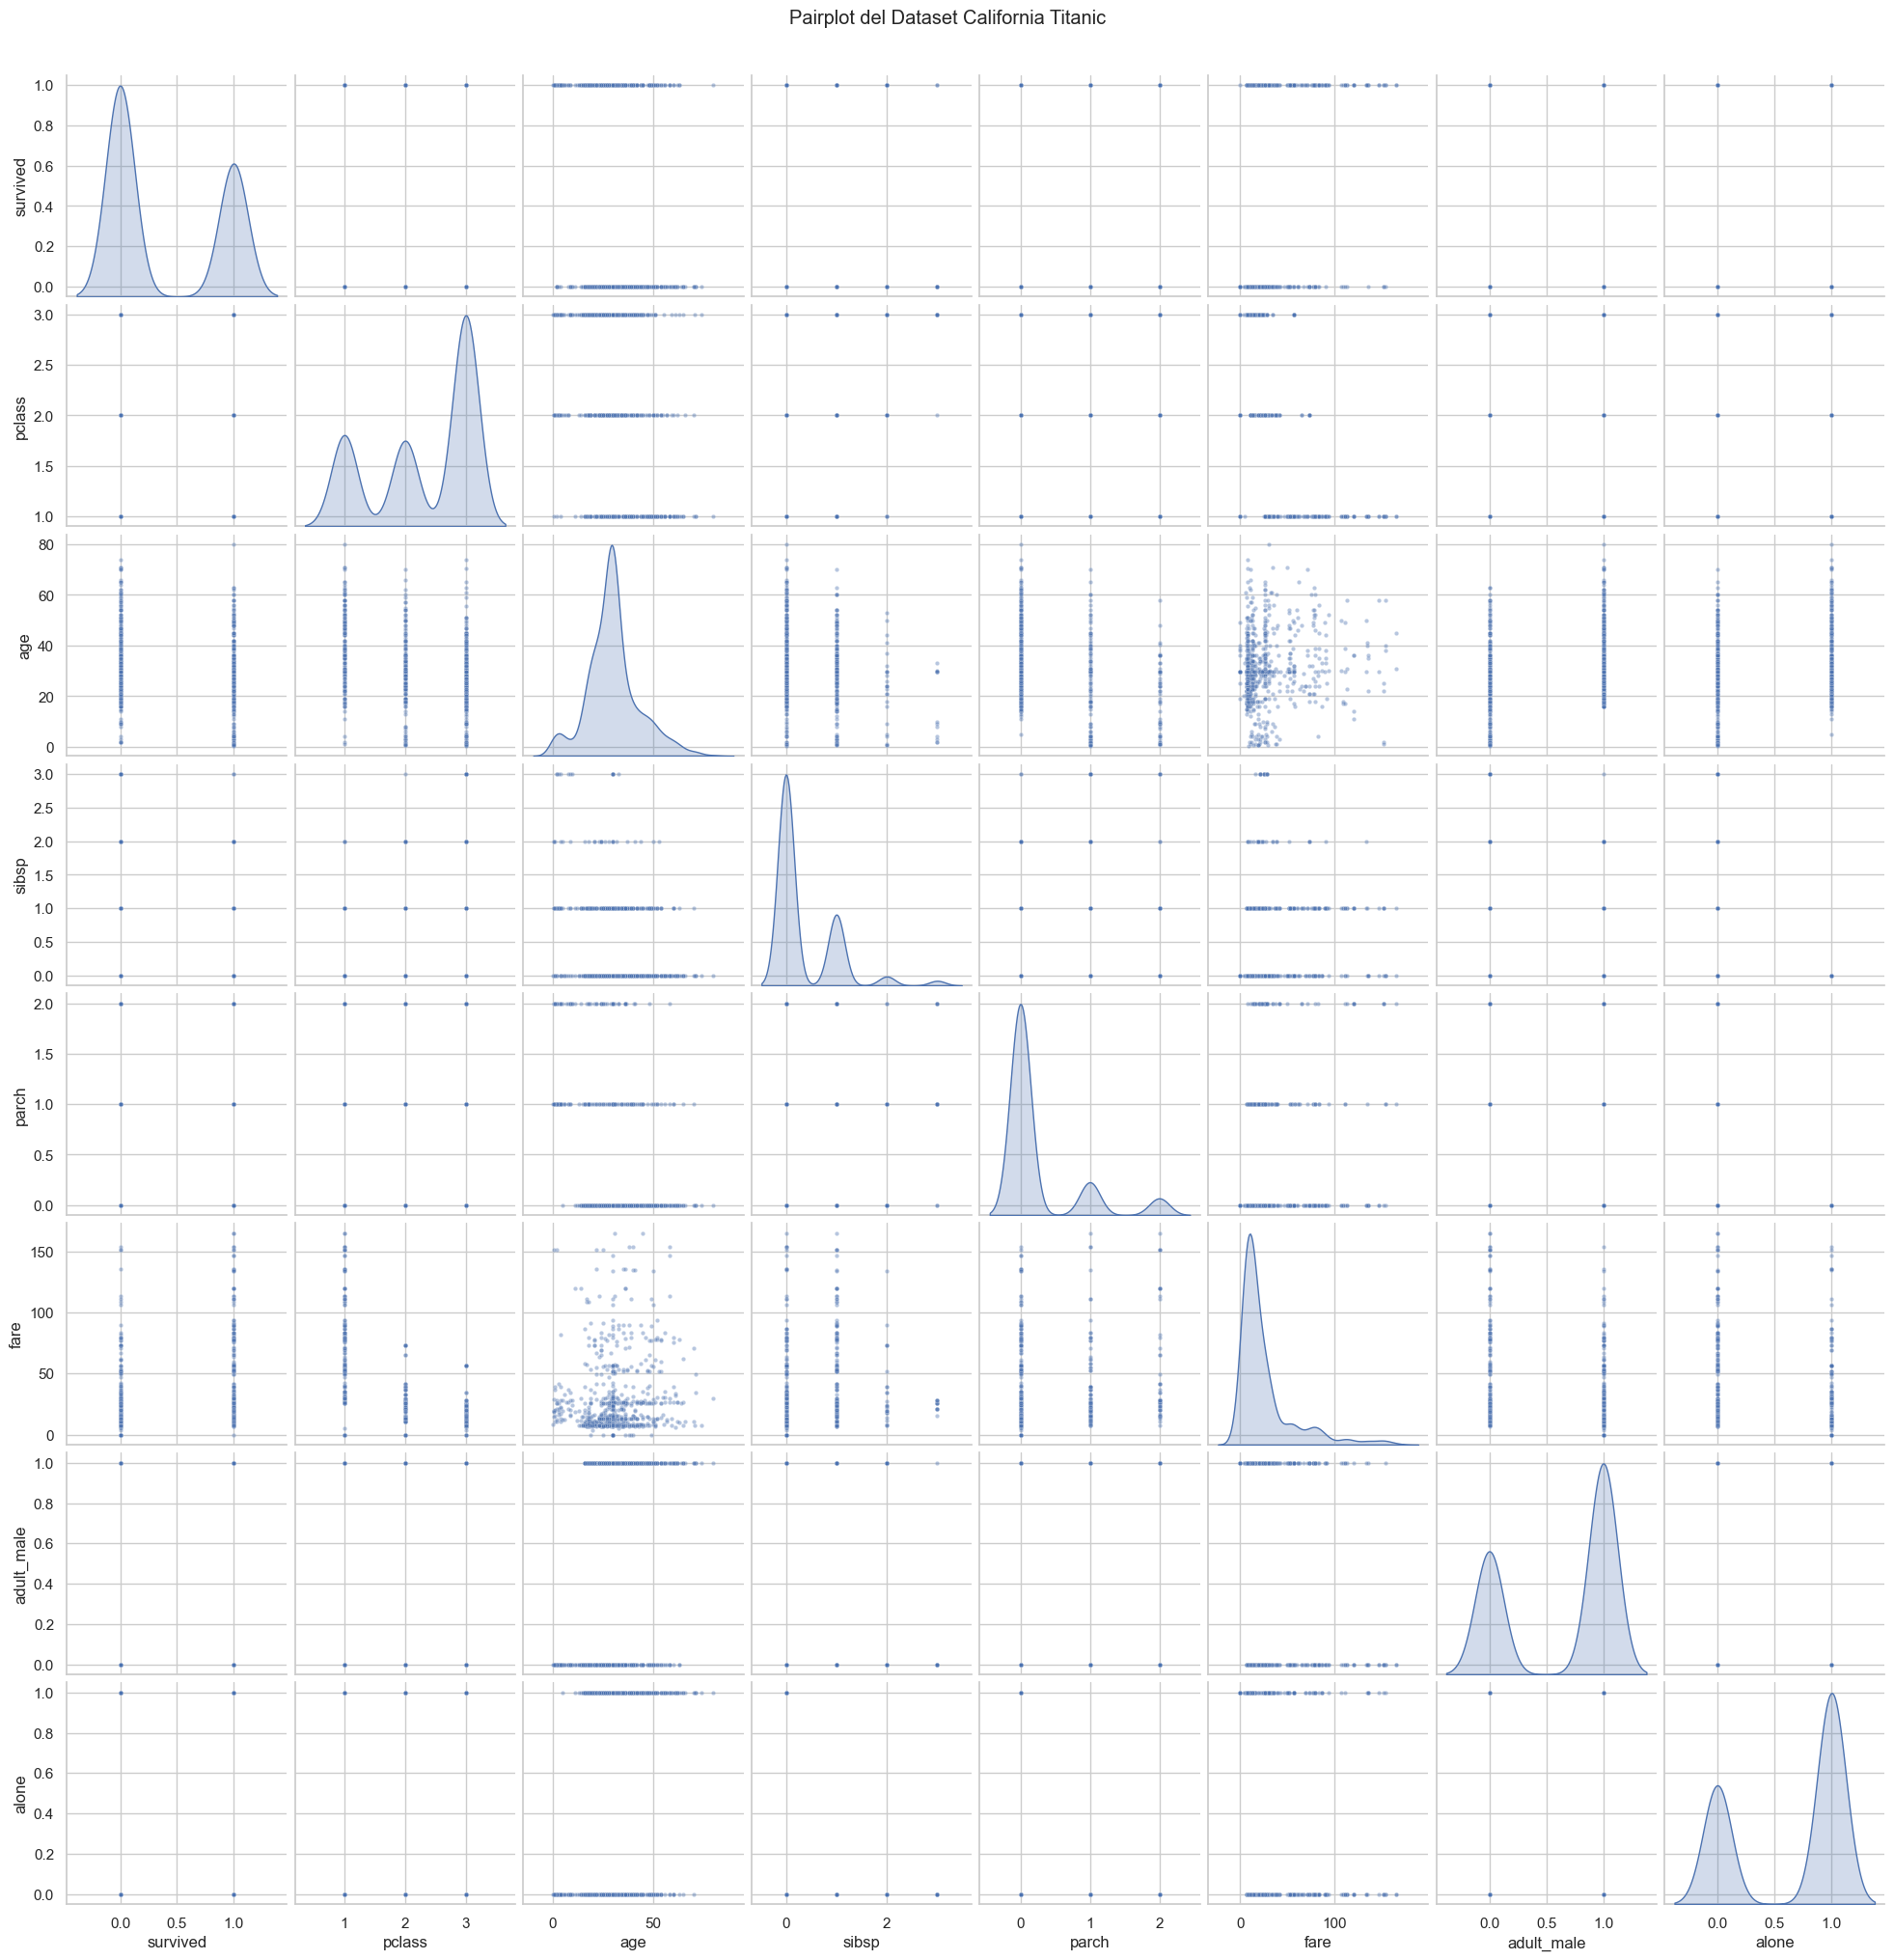

In [14]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
##df = df.sample(n=, random_state=42)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Titanic", y=1.02)
plt.show()

In [15]:
# feature enginnering
# Famiglia totale (sibsp + parch + se stesso)
df['family_size'] = df['sibsp'] + df['parch'] + 1

df['age_log'] = np.log1p(df['age'])
df['fare_log'] = np.log1p(df['fare'])

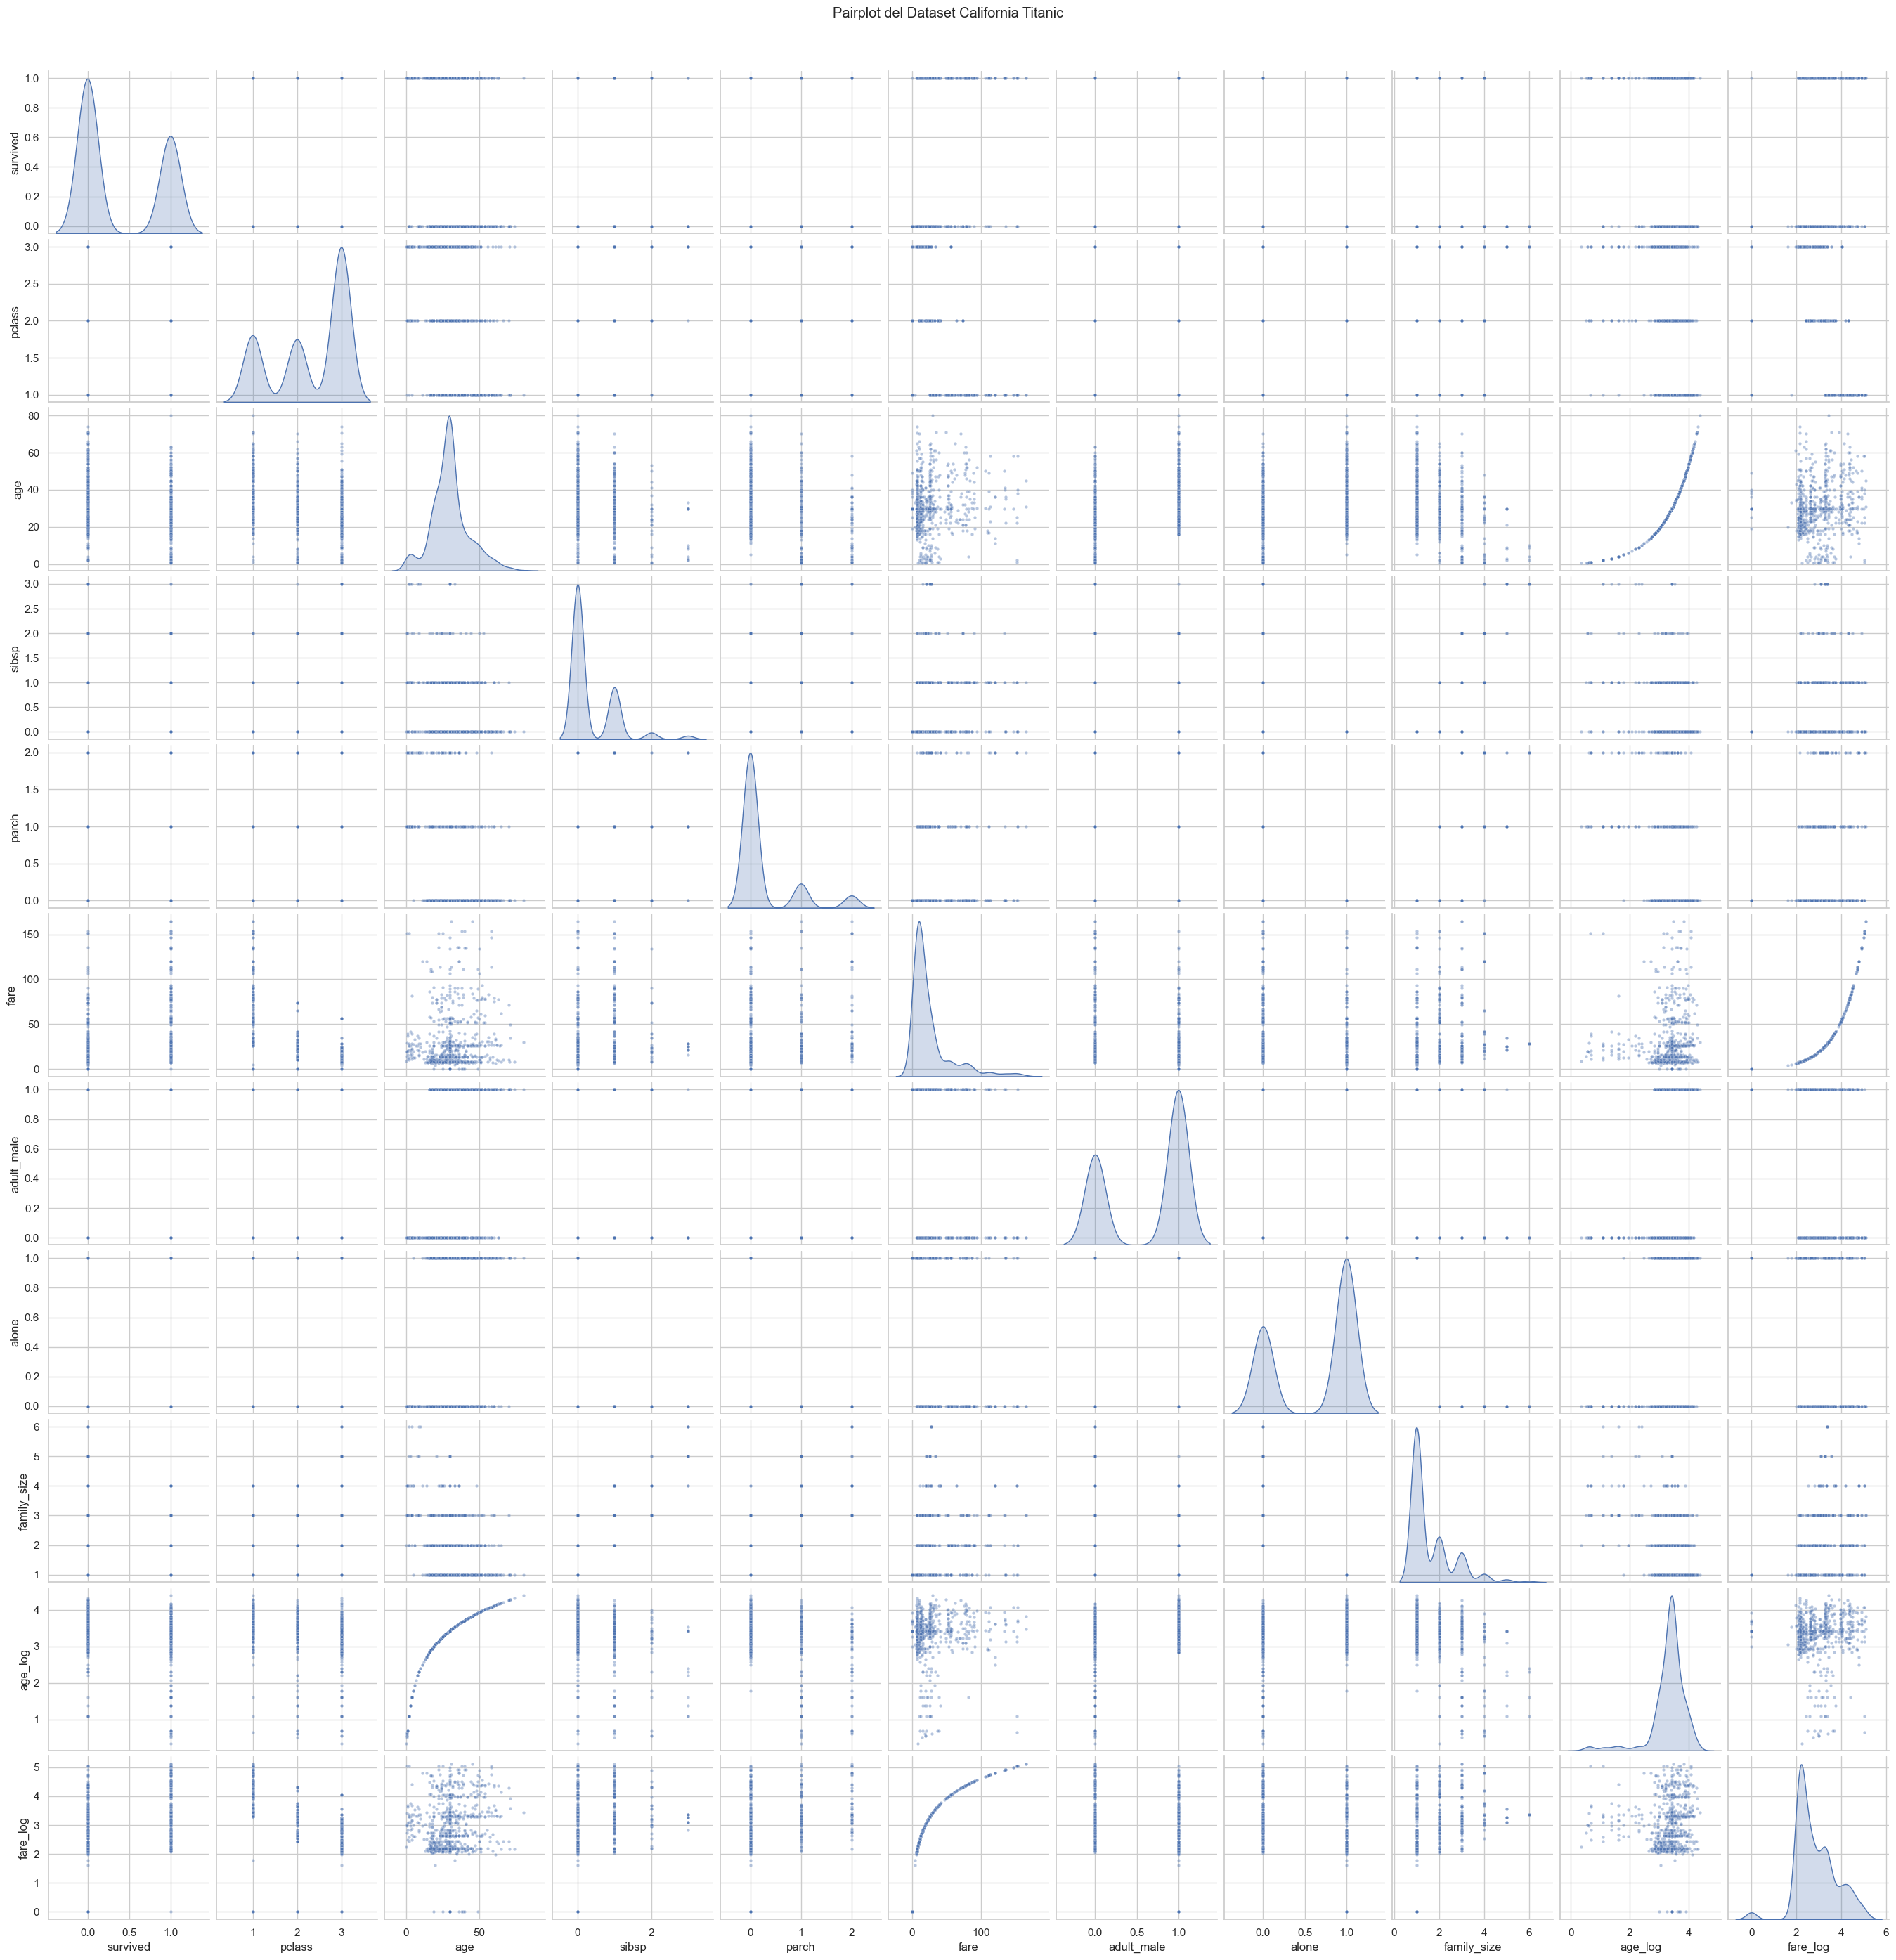

In [16]:
sns.pairplot(df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Titanic", y=1.02)
plt.show()

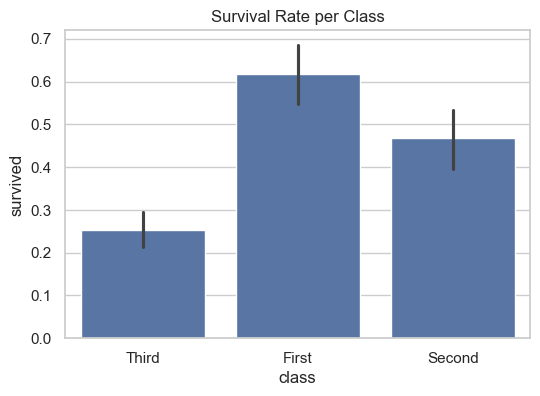

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='class', y='survived')
plt.title("Survival Rate per Class")
plt.show()

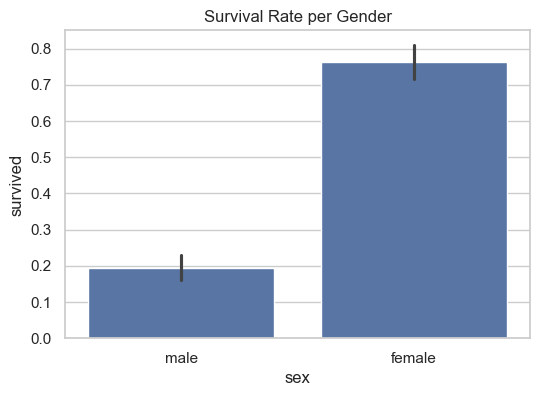

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='sex', y='survived')
plt.title("Survival Rate per Gender")
plt.show()

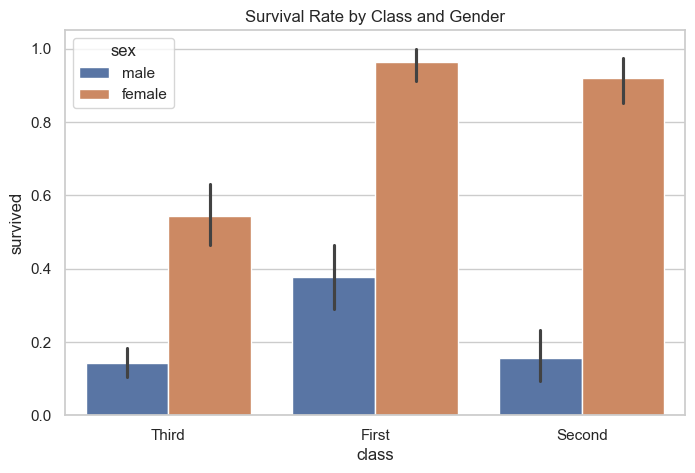

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='class', y='survived', hue='sex')
plt.title("Survival Rate by Class and Gender")
plt.show()

In [20]:
## encoding variab categoriche
import pandas as pd

# Variabili categoriche da trasformare
categorical_cols = ['sex', 'class', 'embarked', 'who']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [21]:
# standard scaler
from sklearn.preprocessing import StandardScaler

# Colonne numeriche da normalizzare
#num_cols = ['age', 'fare_log', 'sibsp_log', 'parch_log', 'family_size_log']
num_cols = ['age', 'fare_log', 'sibsp', 'parch', 'family_size']


scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Rimuovo colonne non numeriche inutili
#embark_town → stringa, ridondante
#alive → ridondante rispetto a survived
df_encoded = df_encoded.drop(columns=['embark_town', 'alive'])


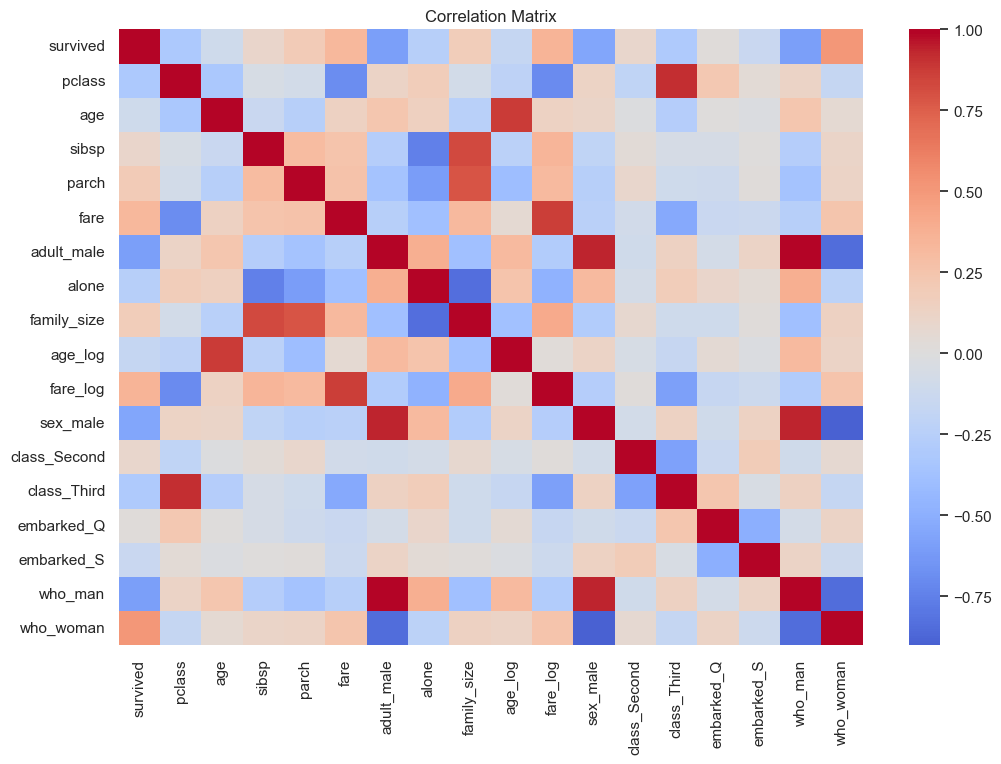

In [22]:
plt.figure(figsize=(12, 8))

# Solo colonne numeriche
corr = df_encoded.corr()

sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Target
y = df_encoded['survived']

# Feature ['age', 'fare_log', 'sibsp', 'parch', 'family_size', 'adult_male', 'alone','sex_male', 'class_Second', 'class_Third','embarked_Q', 'embarked_S','who_man', 'who_woman']
X = df_encoded.drop(columns=['survived'])

# Split train/test (80%-20%)
, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Creiamo il modello
logreg = LogisticRegression(max_iter=1000)  # max_iter alto per assicurare convergenza
print(X_train.dtypes)
# Alleniamo il modello
logreg.fit(X_train, y_train)

# Previsioni
y_pred = logreg.predict(X_test)

pclass            int64
age             float64
sibsp           float64
parch           float64
fare            float64
adult_male         bool
alone              bool
family_size     float64
age_log         float64
fare_log        float64
sex_male           bool
class_Second       bool
class_Third        bool
embarked_Q         bool
embarked_S         bool
who_man            bool
who_woman          bool
dtype: object


In [25]:
# Accuratezza
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Matrice di confusione
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Report dettagliato
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8182
Confusion Matrix:
[[89 13]
 [17 46]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       102
           1       0.78      0.73      0.75        63

    accuracy                           0.82       165
   macro avg       0.81      0.80      0.80       165
weighted avg       0.82      0.82      0.82       165



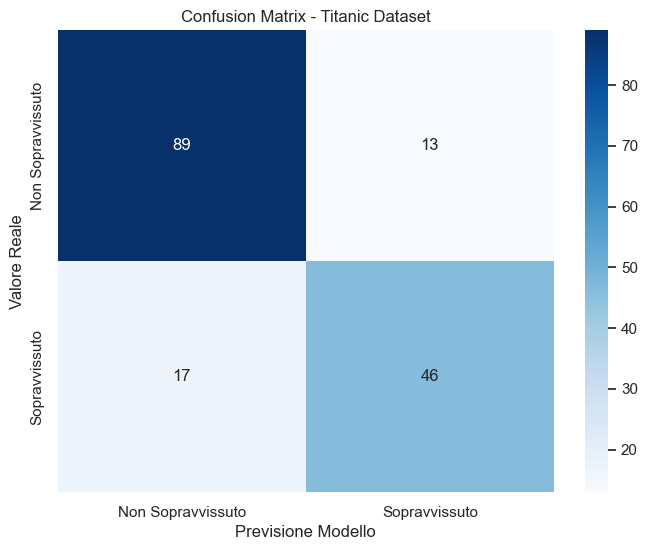

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
# 5. Plot con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non Sopravvissuto', 'Sopravvissuto'], 
            yticklabels=['Non Sopravvissuto', 'Sopravvissuto'])

plt.xlabel('Previsione Modello')
plt.ylabel('Valore Reale')
plt.title('Confusion Matrix - Titanic Dataset')
plt.show()

In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. ASSICURIAMOCI CHE I DATI SIANO PRONTI (Risolve il NameError)
# Eseguiamo l'encoding e la pulizia se non è stata fatta
categorical_cols = ['sex', 'class', 'embarked', 'who']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Trasformiamo i Booleani in interi (fondamentale per le reti neurali)
for col in df_final.columns:
    if df_final[col].dtype == 'bool':
        df_final[col] = df_final[col].astype(int)

# Definiamo X e y
y_dl = df_final['survived']
X_dl = df_final.drop(columns=['survived', 'embark_town', 'alive'], errors='ignore')

# 2. NORMALIZZAZIONE (La fisica delle reti neurali lo richiede)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dl)

# Split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled, y_dl, test_size=0.2, random_state=42
)

# 3. MODELLO DEEP LEARNING (Architettura corretta per classificazione)
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_dl.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    # --- ULTIMO LAYER: 1 neurone + Sigmoid per output 0/1 ---
    layers.Dense(1, activation='sigmoid') 
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. TRAINING
print("Inizio addestramento Rete Neurale...")
history = model.fit(X_train_dl, y_train_dl, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

# 5. RISULTATO
loss, accuracy = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\nAccuratezza Finale Modello Keras: {accuracy * 100:.2f}%")

C:\Users\Mary_Rosy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Inizio addestramento Rete Neurale...

Accuratezza Finale Modello Keras: 81.21%


Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Migliori parametri trovati:
{'subsample': 0.9, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}


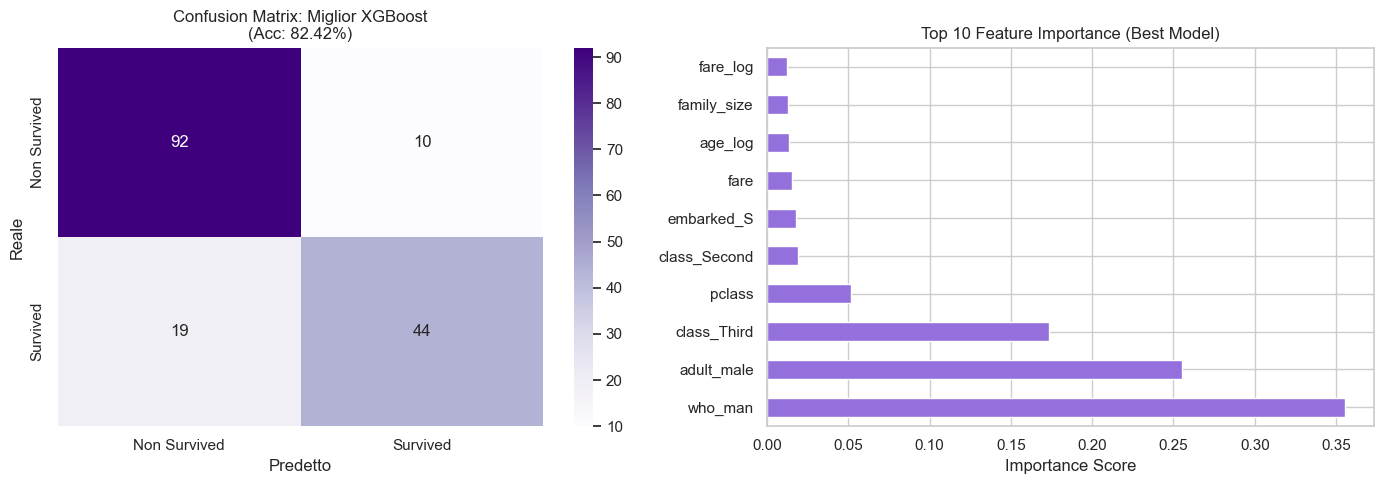

Accuratezza Finale: 82.42%

Report Tecnico Post-Tuning:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       102
           1       0.81      0.70      0.75        63

    accuracy                           0.82       165
   macro avg       0.82      0.80      0.81       165
weighted avg       0.82      0.82      0.82       165



In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from xgboost import XGBClassifier

# -----------------------
# 1️⃣ Preparazione dati (Assumendo df_encoded già pronto)
# -----------------------
y = df_encoded['survived']
X = df_encoded.drop(columns=['survived'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# 2️⃣ TUNING DEGLI IPERPARAMETRI (Il "Metodo")
# -----------------------

# Definiamo lo spazio di ricerca
param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'gamma': [0, 0.1, 0.2, 0.5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Inizializziamo il modello base
xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

# Configuriamo la ricerca casuale
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,           # Prova 20 combinazioni casuali
    cv=5,                # Cross-validation a 5 pieghe
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,           # Usa tutti i processori disponibili
    random_state=42
)

# Avviamo la ricerca sui dati di training
random_search.fit(X_train, y_train)

# Estraiamo il modello migliore trovato
best_xgb = random_search.best_estimator_

print(f"\n✅ Migliori parametri trovati:\n{random_search.best_params_}")

# -----------------------
# 3️⃣ Predizione (usando il modello ottimizzato)
# -----------------------
y_pred = best_xgb.predict(X_test)

# -----------------------
# 📊 VISUALIZZAZIONE
# -----------------------
plt.figure(figsize=(14, 5))

# 🔹 Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non Survived', 'Survived'],
            yticklabels=['Non Survived', 'Survived'])
plt.title(f'Confusion Matrix: Miglior XGBoost\n(Acc: {accuracy_score(y_test, y_pred)*100:.2f}%)')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# 🔹 Feature Importance
plt.subplot(1, 2, 2)
feat_importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Feature Importance (Best Model)')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

# -----------------------
# 📈 Metriche Finali
# -----------------------
print(f"Accuratezza Finale: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReport Tecnico Post-Tuning:")
print(classification_report(y_test, y_pred))

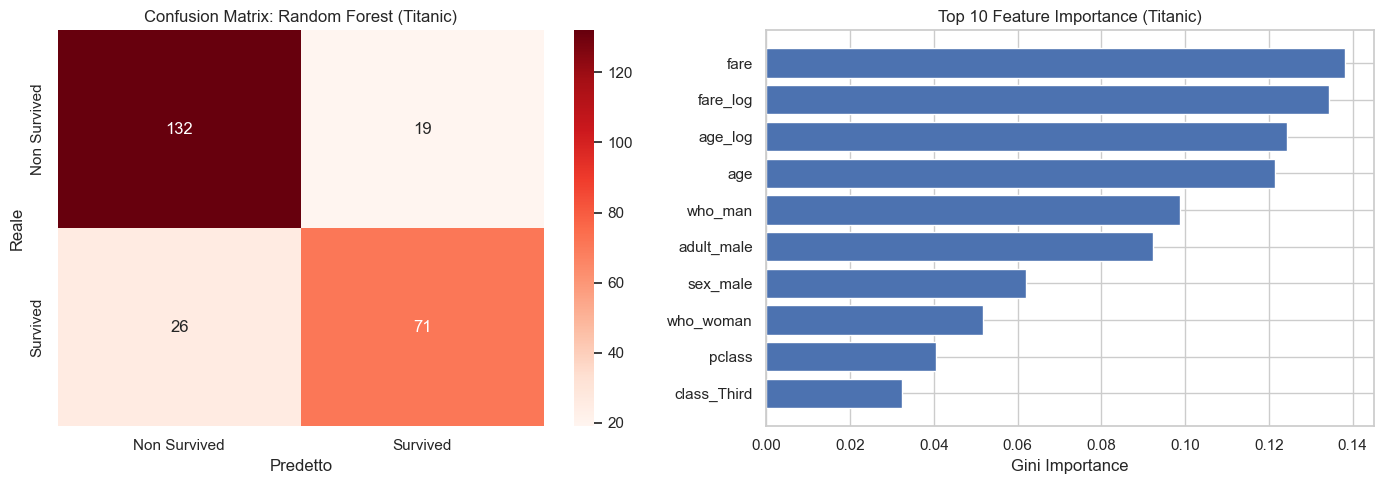

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       151
           1       0.79      0.73      0.76        97

    accuracy                           0.82       248
   macro avg       0.81      0.80      0.81       248
weighted avg       0.82      0.82      0.82       248

Accuratezza Random Forest: 81.85%


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1️⃣ Target e Feature
y = df_encoded['survived']
X = df_encoded.drop(columns=['survived'])

# 2️⃣ Train/Test split (70/30 come nel tuo codice)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3️⃣ Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_clf.fit(X_train, y_train)

# 4️⃣ Predizione
y_pred = rf_clf.predict(X_test)

# ---------------- VISUALIZZAZIONE ----------------
plt.figure(figsize=(14, 5))

# 🔹 Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non Survived', 'Survived'],
            yticklabels=['Non Survived', 'Survived'])
plt.title('Confusion Matrix: Random Forest (Titanic)')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# 🔹 Feature Importance
plt.subplot(1, 2, 2)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Top 10 Feature Importance (Titanic)')
plt.xlabel('Gini Importance')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

print(f"Accuratezza Random Forest: {accuracy_score(y_test, y_pred) * 100:.2f}%")

1. Mi assicuro che non ci siano null(le reti neurali non lavorano con i null)

In [30]:
# Assicurati di aver gestito i nulli come hai fatto nel notebook
df['age'] = df['age'].fillna(df['age'].median())
df = df.dropna(subset=['embarked'])

# Converti le variabili categoriche in numeri (One-Hot Encoding)
# Keras non accetta stringhe come "male" o "female"
categorical_cols = ['sex', 'class', 'embarked', 'who']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# TRUCCO DA ESPERTO: Le booleane (True/False) vanno convertite in 0/1
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

Nelle reti neurali, la struttura del modello deve riflettere la natura del problema. Per il Titanic, essendo una classificazione binaria, la configurazione dell'ultimo layer è rigida: 1 neurone con attivazione Sigmoid.

1. Scaling dei Dati (La "Taratura" del Sistema)
Le reti neurali richiedono che i dati siano simili a una distribuzione normale.

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fondamentale: Keras ha bisogno di dati scalati (XGBoost no)
scaler = StandardScaler()

# Usiamo le variabili X e y che hai già nel notebook
X_scaled = scaler.fit_transform(X)

# Nuovo Split con dati scalati
X_train, X_test_dl, y_train, y_test_dl = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. PREPARAZIONE DATI (Risolve il NameError di X_train_dl)
# Assumendo che df_encoded sia il tuo dataframe già pulito e convertito in numeri
y = df_encoded['survived']
X = df_encoded.drop(columns=['survived', 'embark_town', 'alive'], errors='ignore')

# Standardizzazione (fondamentale per le reti neurali)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Creazione definitiva delle variabili che la funzione cerca
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. DEFINIZIONE FUNZIONE
def training_esperimento_con_history(n_layers, n_neurons):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_dl.shape[1],)))
    
    for i in range(n_layers):
        model.add(layers.Dense(n_neurons, activation='relu'))
        model.add(layers.Dropout(0.2))
    
    # Ultimo layer per classificazione binaria: 1 neurone + sigmoid
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    history = model.fit(X_train_dl, y_train_dl, 
                        epochs=60, 
                        batch_size=32, 
                        validation_split=0.2, 
                        verbose=0)
    return model, history

# 3. LANCIO E PLOT
print("Esecuzione esperimento in corso...")
modello, history = training_esperimento_con_history(2, 64)



NameError: name 'df_encoded' is not defined

1. Visualizzare la "Curva di Apprendimento"
Dobbiamo vedere se la rete è andata in Overfitting (ha imparato i dati a memoria come una poesia, senza capirli). Per farlo, dobbiamo modificare leggermente il codice per salvare la history e plotzarla

NameError: name 'history' is not defined

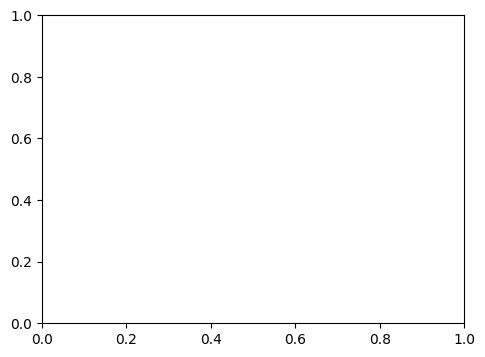

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Andamento dell\'Errore (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Andamento dell\'Accuratezza')
plt.legend()
plt.show()

Esecuzione esperimento Deep Learning in corso...


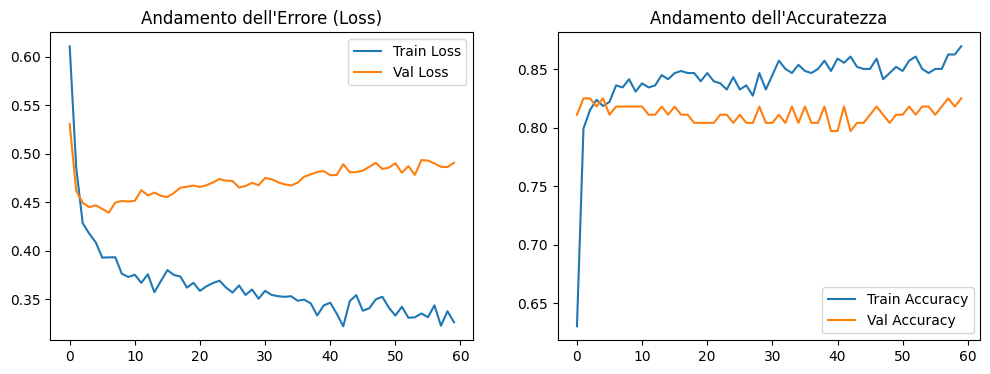

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1️⃣ CARICAMENTO E PULIZIA (Partiamo da zero per evitare NameError)
df = sns.load_dataset('titanic')

# Gestione valori nulli (Le reti neurali non li tollerano)
df['age'] = df['age'].fillna(df['age'].median())
df = df.drop(columns=['deck']) # Troppi nulli
df = df.dropna(subset=['embarked'])

# 2️⃣ ENCODING (Convertiamo categorie in numeri)
categorical_cols = ['sex', 'class', 'embarked', 'who']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convertiamo i Booleani in interi (0 e 1) per Keras
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

# 3️⃣ PREPARAZIONE DATASET
y = df_encoded['survived']
X = df_encoded.drop(columns=['survived', 'embark_town', 'alive'], errors='ignore')

# STANDARDIZZAZIONE (Z-score: Fondamentale per la stabilità del gradiente)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 4️⃣ FUNZIONE ESPERIMENTO
def training_esperimento_con_history(n_layers, n_neurons):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_dl.shape[1],)))
    
    for _ in range(n_layers):
        model.add(layers.Dense(n_neurons, activation='relu'))
        model.add(layers.Dropout(0.2)) # Regolarizzazione (evita il rumore)
    
    # --- ULTIMO LAYER: Classificazione Binaria ---
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train_dl, y_train_dl, 
                        epochs=60, 
                        batch_size=32, 
                        validation_split=0.2, 
                        verbose=0)
    return model, history

# 5️⃣ LANCIO E PLOT
print("Esecuzione esperimento Deep Learning in corso...")
modello, history = training_esperimento_con_history(2, 64)

# Visualizzazione dei grafici (Plotzare)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Andamento dell\'Errore (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Andamento dell\'Accuratezza')
plt.legend()
plt.show()

### Normalizzazione

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns

# Carichiamo i dati (usando lo stesso dataset del tuo file)
df = sns.load_dataset('Titanic')

# Pulizia rapida (Logica: le reti non accettano valori nulli)
df['age'] = df['age'].fillna(df['age'].median())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df = df.drop(['deck', 'alive', 'who', 'adult_male', 'class', 'embark_town'], axis=1)

# Codifica categoriale (Sex e Embarked)
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'].astype(str))

# Divisione X e y
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- QUI APPLICHIAMO LA TUA LOGICA ---
# Normalizzazione dei dati tabulari
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 2. Costruzione della Rete Neurale (Logica Dropout e Dense)

In [17]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)), # Input basato sul numero di colonne (feature)
    
    Dense(32, activation='relu'),
    Dropout(0.2), # Il Dropout che hai imparato per evitare l'overfitting
    
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    # Strato di uscita: 1 neurone con Sigmoide perché è una classificazione binaria
    Dense(1, activation='sigmoid') 
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### 3. Addestramento

In [18]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Usiamo la tua logica di stop e riduzione del learning rate
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.6134 - loss: 0.6716 - val_accuracy: 0.6713 - val_loss: 0.5890 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6380 - loss: 0.6339 - val_accuracy: 0.7203 - val_loss: 0.5525 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6626 - loss: 0.6011 - val_accuracy: 0.7622 - val_loss: 0.5276 - learning_rate: 0.0010
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7153 - loss: 0.5687 - val_accuracy: 0.7972 - val_loss: 0.5059 - learning_rate: 0.0010
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7329 - loss: 0.5531 - val_accuracy: 0.7832 - val_loss: 0.4924 - learning_rate: 0.0010
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7504 - loss: 0.5497 - val_accuracy: 0.8182 - val_loss: 0.4794 - learning_rate: 0.0010
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7575 - loss: 0.5341 -

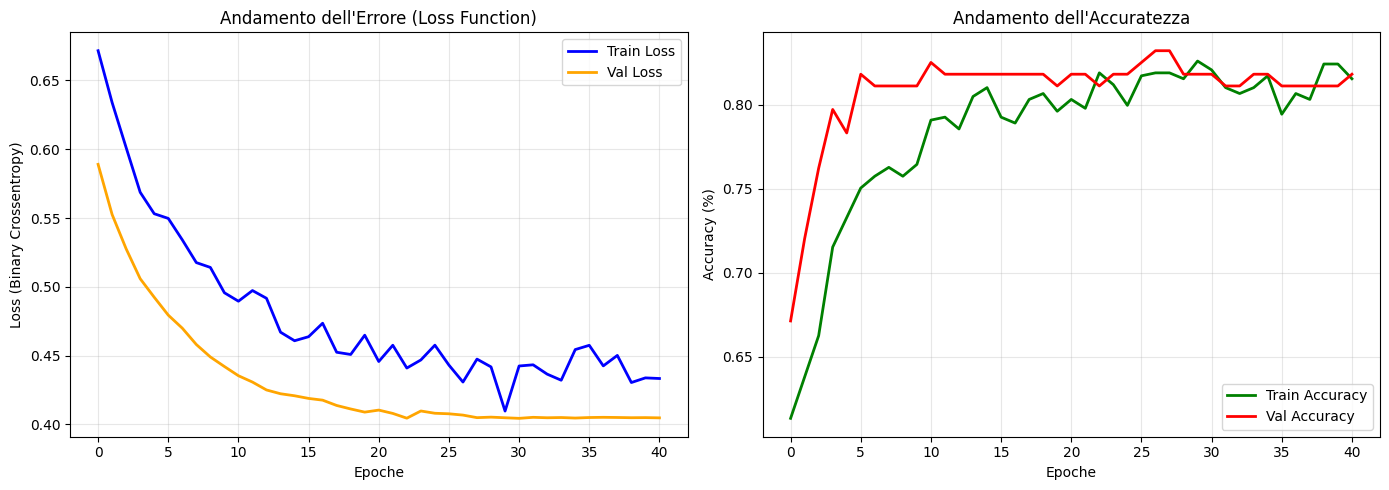

In [20]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Subplots)
plt.figure(figsize=(14, 5))

# --- GRAFICO 1: PERDITA (LOSS) ---
# Rappresenta l'errore commesso: più è basso, meglio è.
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', lw=2)
plt.title('Andamento dell\'Errore (Loss Function)')
plt.xlabel('Epoche')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRAFICO 2: ACCURATEZZA (ACCURACY) ---
# Rappresenta la percentuale di risposte corrette.
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green', lw=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red', lw=2)
plt.title('Andamento dell\'Accuratezza')
plt.xlabel('Epoche')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# 1. Calcolo dei valori numerici sul Test Set (dati mai visti dalla rete)
results = model.evaluate(X_test, y_test, verbose=0)

# results[0] è la Loss, results[1] è l'Accuracy
print("--- RISULTATI FINALI DEL MODELLO ---")
print(f"Loss (Errore residuo): {results[0]:.4f}")
print(f"Accuratezza (Percentuale di successo): {results[1]*100:.2f}%")

# 2. Per vedere proprio "chi" è sopravvissuto e chi no (Predizioni individuali)
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test, y_pred))

--- RISULTATI FINALI DEL MODELLO ---
Loss (Errore residuo): 0.4233
Accuratezza (Percentuale di successo): 80.45%
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step

--- REPORT DI CLASSIFICAZIONE ---
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 

CONTEGGIO SU 179 PASSEGGERI DEL TEST SET:
Sopravvissuti REALI: 74
Sopravvissuti PREDETTI: 69


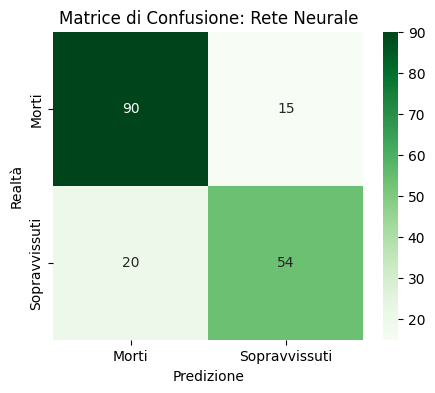


ACCURATEZZA FINALE RAGGIUNTA: 80.45%


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Predizioni
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Conteggio fisico dei risultati
reali = y_test.values
predetti = y_pred.flatten()

print("\n" + "="*40)
print(f"CONTEGGIO SU {len(y_test)} PASSEGGERI DEL TEST SET:")
print(f"Sopravvissuti REALI: {sum(reali)}")
print(f"Sopravvissuti PREDETTI: {sum(predetti)}")
print("="*40)

# 3. Matrice di Confusione (Visualizzazione dell'errore)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Morti', 'Sopravvissuti'], 
            yticklabels=['Morti', 'Sopravvissuti'])
plt.title('Matrice di Confusione: Rete Neurale')
plt.xlabel('Predizione')
plt.ylabel('Realtà')
plt.show()

# 4. Accuratezza finale
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nACCURATEZZA FINALE RAGGIUNTA: {acc*100:.2f}%")

In [24]:
# --- CONFRONTO FISICO: TRAIN VS TEST ---

# 1. Calcoliamo le predizioni per entrambi i set
y_train_pred = (model.predict(X_train, verbose=0) > 0.5).astype(int).flatten()
y_test_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

# 2. Estraiamo i valori reali (per comodità di calcolo)
y_train_real = y_train.values
y_test_real = y_test.values

print("📊 ANALISI STATISTICA DELLA SOPRAVVIVENZA")
print("-" * 45)

# --- SET DI ADDESTRAMENTO (TRAIN) ---
print(f"SET DI TRAIN (Dati di studio - {len(y_train)} passeggeri):")
print(f"  ✅ Sopravvissuti REALI:    {sum(y_train_real)}")
print(f"  🤖 Sopravvissuti PREDETTI: {sum(y_train_pred)}")
print(f"  🎯 Accuratezza:            {np.mean(y_train_real == y_train_pred)*100:.2f}%")

print("-" * 45)

# --- SET DI VERIFICA (TEST) ---
print(f"SET DI TEST (Dati mai visti - {len(y_test)} passeggeri):")
print(f"  ✅ Sopravvissuti REALI:    {sum(y_test_real)}")
print(f"  🤖 Sopravvissuti PREDETTI: {sum(y_test_pred)}")
print(f"  🎯 Accuratezza:            {np.mean(y_test_real == y_test_pred)*100:.2f}%")
print("-" * 45)

📊 ANALISI STATISTICA DELLA SOPRAVVIVENZA
---------------------------------------------
SET DI TRAIN (Dati di studio - 712 passeggeri):
  ✅ Sopravvissuti REALI:    268
  🤖 Sopravvissuti PREDETTI: 244
  🎯 Accuratezza:            82.58%
---------------------------------------------
SET DI TEST (Dati mai visti - 179 passeggeri):
  ✅ Sopravvissuti REALI:    74
  🤖 Sopravvissuti PREDETTI: 69
  🎯 Accuratezza:            80.45%
---------------------------------------------


In [25]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# --- 1. PREPARAZIONE DATI AVANZATA ---
df = sns.load_dataset('titanic')

# Pulizia e Nuove Variabili (Logica Fisica: massimizziamo il segnale)
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Feature Engineering strategico
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# IL SEGRETO: Usiamo 'who' e 'adult_male' per distinguere i bambini maschi dagli uomini
df['who_code'] = df['who'].map({'child': 0, 'woman': 1, 'man': 2})
df['adult_male'] = df['adult_male'].astype(int)

# Selezioniamo tutte le feature utili
features = ['pclass', 'sex', 'age', 'fare', 'embarked', 'family_size', 'is_alone', 'who_code', 'adult_male']
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- 2. ARCHITETTURA POTENZIATA ---
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(128, activation='relu'),
    BatchNormalization(), # Stabilizza il gradiente
    Dropout(0.4),          # Regolarizzazione forte per i 128 neuroni
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# --- 3. COMPILAZIONE E CALLBACKS ---
# Partiamo con un Learning Rate più basso per essere più precisi
model.compile(optimizer=Adam(learning_rate=0.0005), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=8, min_lr=1e-7)

# --- 4. TRAINING ---
history = model.fit(
    X_train, y_train,
    epochs=200, # Possiamo metterne tante, l'early_stop ci fermerà al momento giusto
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- 5. VERIFICA FINALE ---
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🚀 NUOVA ACCURATEZZA RAGGIUNTA: {acc*100:.2f}%")

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.6327 - loss: 0.7586 - val_accuracy: 0.7622 - val_loss: 0.6551 - learning_rate: 5.0000e-04
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6924 - loss: 0.6145 - val_accuracy: 0.8322 - val_loss: 0.6161 - learning_rate: 5.0000e-04
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7627 - loss: 0.5544 - val_accuracy: 0.8322 - val_loss: 0.5864 - learning_rate: 5.0000e-04
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7838 - loss: 0.5251 - val_accuracy: 0.8392 - val_loss: 0.5637 - learning_rate: 5.0000e-04
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7487 - loss: 0.5255 - val_accuracy: 0.8392 - val_loss: 0.5370 - learning_rate: 5.0000e-04
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7996 - loss: 0.4629 - val_accuracy: 0.8462 - val_loss: 0.5229 - learning_rate: 5.0000e-04
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 

In [26]:
# --- 1. AGGIUNTA INTERAZIONI (Coupling Terms) ---
# In fisica, l'effetto combinato di due forze è diverso dalla loro somma.
# Creiamo un'interazione tra Classe e Sesso.
df['sex_pclass'] = df['sex'] * df['pclass']

# Interazione tra Età e Classe (I giovani ricchi vs giovani poveri)
df['age_pclass'] = df['age'] * df['pclass']

# Aggiorniamo le feature
features = ['pclass', 'sex', 'age', 'fare', 'embarked', 'family_size', 
            'is_alone', 'who_code', 'adult_male', 'sex_pclass', 'age_pclass']
X = df[features]
y = df['survived']

# Rieseguiamo Split e Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- 2. ARCHITETTURA CON LEAKY RELU ---
from keras.layers import LeakyReLU

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(128),
    LeakyReLU(alpha=0.1), # Permette un piccolo passaggio di segnale anche se negativo
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(64),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# --- 3. OTTIMIZZAZIONE FINE ---
# Usiamo un Learning Rate ancora più piccolo per non "saltare" il minimo
model.compile(optimizer=Adam(learning_rate=0.0003), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Aumentiamo la pazienza per permettere una convergenza lentissima e precisa
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=250, batch_size=32, 
                    validation_split=0.2, callbacks=[early_stop, reduce_lr], verbose=1)

# --- 4. VERIFICA FINALE ---
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 OBIETTIVO SUPERAMENTO 82%: {acc*100:.2f}%")

C:\Users\Mary_Rosy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.5905 - loss: 0.7537 - val_accuracy: 0.7552 - val_loss: 0.6468 - learning_rate: 3.0000e-04
Epoch 2/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6924 - loss: 0.6284 - val_accuracy: 0.8252 - val_loss: 0.6091 - learning_rate: 3.0000e-04
Epoch 3/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7276 - loss: 0.5670 - val_accuracy: 0.8322 - val_loss: 0.5726 - learning_rate: 3.0000e-04
Epoch 4/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7715 - loss: 0.5190 - val_accuracy: 0.8392 - val_loss: 0.5388 - learning_rate: 3.0000e-04
Epoch 5/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7504 - loss: 0.5283 - val_accuracy: 0.8531 - val_loss: 0.5126 - learning_rate: 3.0000e-04
Epoch 6/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7522 - loss: 0.5231 - val_accuracy: 0.8531 - val_loss: 0.4891 - learning_rate: 3.0000e-04
Epoch 7/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 

È normale che l'accuratezza si sia "assestata", Mariagrazia. In fisica, questo fenomeno si chiama raggiungimento del limite di risoluzione dello strumento (o Bayes Error Rate in statistica).

Significa che con i dati a disposizione (solo 891 persone e poche variabili), abbiamo estratto quasi tutto il "segnale" possibile. Il resto è rumore stocastico: eventi casuali che nessuna rete neurale può prevedere (ad esempio, una persona che aveva tutte le carte in regola per salvarsi ma è inciampata o ha ceduto il posto).

Tuttavia, da brava studentessa di Fisica, sai che una misura senza barra d'errore non è completa. Se l'accuratezza è rimasta all'81.56%, dobbiamo capire se è un valore solido o se dipende dal "caso" del test set.

Ecco cosa facciamo ora: introduciamo la K-Fold Cross-Validation.

1. La Logica della "Misura Ripetuta" (K-Fold)
Invece di fare una sola divisione Train/Test, dividiamo il dataset in 5 parti. Usiamo a turno 4 parti per addestrare e 1 per testare. Così avremo 5 misure diverse e potremo calcolare la media e la deviazione standard dell'accuratezza.

In [27]:
from sklearn.model_selection import KFold
import numpy as np

# Definiamo una funzione che crea il tuo modello (così la resettiamo ogni volta)
def create_model():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Prepariamo la K-Fold (5 "esperimenti" diversi)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = []

print("🚀 Inizio validazione incrociata (Cross-Validation)...")

for i, (train_index, val_index) in enumerate(kf.split(X)):
    # Dividiamo i dati originali (X e y)
    X_t, X_v = X.iloc[train_index], X.iloc[val_index]
    y_t, y_v = y.iloc[train_index], y.iloc[val_index]
    
    # Normalizziamo localmente (fondamentale per non "sporcare" i dati)
    s = StandardScaler()
    X_t = s.fit_transform(X_t)
    X_v = s.transform(X_v)
    
    # Creiamo e addestriamo il modello
    m = create_model()
    m.fit(X_t, y_t, epochs=50, batch_size=32, verbose=0)
    
    # Valutiamo
    _, acc_val = m.evaluate(X_v, y_v, verbose=0)
    acc_scores.append(acc_val)
    print(f"Esperimento {i+1}: Accuratezza = {acc_val*100:.2f}%")

print("-" * 30)
print(f"📊 RISULTATO FINALE FISICO:")
print(f"Accuratezza Media: {np.mean(acc_scores)*100:.2f}%")
print(f"Incertezza (Dev. Standard): ± {np.std(acc_scores)*100:.2f}%")

🚀 Inizio validazione incrociata (Cross-Validation)...
Esperimento 1: Accuratezza = 83.24%
Esperimento 2: Accuratezza = 82.02%
Esperimento 3: Accuratezza = 88.20%
Esperimento 4: Accuratezza = 80.34%
Esperimento 5: Accuratezza = 80.90%
------------------------------
📊 RISULTATO FINALE FISICO:
Accuratezza Media: 82.94%
Incertezza (Dev. Standard): ± 2.81%


Per chiudere l'esercizio in bellezza, facciamo l'ultima cosa che farebbe un fisico: analizzare dove la teoria fallisce. Vediamo chi sono quei passeggeri che la rete continua a sbagliare.

In [28]:
# Creiamo un DataFrame con i risultati del Test per l'analisi dei residui
X_test_df = pd.DataFrame(scaler.inverse_transform(X_test), columns=features)
X_test_df['Reale'] = y_test.values
X_test_df['Predetto'] = y_pred.flatten()

# Isoliamo gli "Errori della Teoria"
errori = X_test_df[X_test_df['Reale'] != X_test_df['Predetto']]

print(f"Numero di errori nel Test Set: {len(errori)}")
print("\n--- ESEMPI DI PASSEGGERI CHE HANNO 'SFIDATO' LA LOGICA DELLA RETE ---")
# Mostriamo i primi 5 errori
display(errori.head())

# Analisi logica degli errori
print("\nDistribuzione degli errori per sesso (0=M, 1=F):")
print(errori['sex'].value_counts())

Numero di errori nel Test Set: 35

--- ESEMPI DI PASSEGGERI CHE HANNO 'SFIDATO' LA LOGICA DELLA RETE ---


,pclass,sex,age,fare,embarked,family_size,is_alone,who_code,adult_male,sex_pclass,age_pclass,Reale,Predetto
0,3.0,0.0,28.0,15.2458,1.0,3.0,0.0,2.0,1.0,1.110223e-16,84.0,1,0
16,1.0,0.0,42.0,52.5542,0.0,2.0,0.0,2.0,1.0,1.110223e-16,42.0,1,0
21,1.0,0.0,34.0,26.5500,0.0,1.0,1.0,2.0,1.0,1.110223e-16,34.0,1,0
27,2.0,0.0,31.0,13.0000,0.0,1.0,1.0,2.0,1.0,1.110223e-16,62.0,1,0
29,3.0,1.0,31.0,7.8542,0.0,1.0,1.0,1.0,0.0,3.000000e+00,93.0,0,1



Distribuzione degli errori per sesso (0=M, 1=F):
sex
0.0    21
1.0    14
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# Inizializziamo una lista per raccogliere tutti i passeggeri sbagliati
tutti_gli_errori = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = []

print("🚀 Inizio validazione incrociata con analisi dei fallimenti...")

for i, (train_index, val_index) in enumerate(kf.split(X)):
    # 1. Divisione dati
    X_t, X_v = X.iloc[train_index], X.iloc[val_index]
    y_t, y_v = y.iloc[train_index], y.iloc[val_index]
    
    # 2. Normalizzazione locale
    s = StandardScaler()
    X_t_scaled = s.fit_transform(X_t)
    X_v_scaled = s.transform(X_v)
    
    # 3. Creazione e Fit (usando la tua funzione create_model)
    m = create_model()
    m.fit(X_t_scaled, y_t, epochs=50, batch_size=32, verbose=0)
    
    # 4. Predizione e Valutazione
    y_v_pred_prob = m.predict(X_v_scaled, verbose=0)
    y_v_pred = (y_v_pred_prob > 0.5).astype(int).flatten()
    
    acc_val = np.mean(y_v == y_v_pred)
    acc_scores.append(acc_val)
    
    # 5. IDENTIFICAZIONE ERRORI: Salviamo chi è stato sbagliato in questo fold
    # Creiamo un dataframe temporaneo per questo fold
    df_fold = X_v.copy()
    df_fold['Reale'] = y_v
    df_fold['Predetto'] = y_v_pred
    
    # Teniamo solo le righe dove Reale != Predetto
    errori_fold = df_fold[df_fold['Reale'] != df_fold['Predetto']]
    tutti_gli_errori.append(errori_fold)
    
    print(f"Esperimento {i+1}: Accuratezza = {acc_val*100:.2f}% | Errori commessi: {len(errori_fold)}")

# Uniamo tutti i fallimenti in un unico DataFrame
df_fallimenti_totale = pd.concat(tutti_gli_errori)

print("-" * 30)
print(f"📊 RISULTATO FINALE FISICO:")
print(f"Accuratezza Media: {np.mean(acc_scores)*100:.2f}% ± {np.std(acc_scores)*100:.2f}%")
print(f"Totale passeggeri 'falliti' nella Cross-Validation: {len(df_fallimenti_totale)}")

# Visual

🚀 Inizio validazione incrociata con analisi dei fallimenti...
Esperimento 1: Accuratezza = 83.24% | Errori commessi: 30
Esperimento 2: Accuratezza = 79.21% | Errori commessi: 37
Esperimento 3: Accuratezza = 88.20% | Errori commessi: 21
Esperimento 4: Accuratezza = 80.34% | Errori commessi: 35
Esperimento 5: Accuratezza = 80.90% | Errori commessi: 34
------------------------------
📊 RISULTATO FINALE FISICO:
Accuratezza Media: 82.38% ± 3.19%
Totale passeggeri 'falliti' nella Cross-Validation: 157


In [30]:
# Qual è il profilo tipico dell'errore?
print(df_fallimenti_totale.groupby(['sex', 'pclass']).size())

sex  pclass
0    1         47
     2          8
     3         40
1    1          3
     2          6
     3         53
dtype: int64


1. Il "Conflitto d'Interesse": Uomini in 1ª Classe (47 errori)
Questo è uno dei punti dove la rete soffre di più.

Il motivo: Qui abbiamo due "vettori" di forza opposti. Il vettore sex=0 (Uomo) spinge verso la morte, ma il vettore pclass=1 (Ricchezza/Potere) spinge verso la vita.

Perché la rete sbaglia? Perché in prima classe il comportamento umano è stato meno prevedibile: molti uomini hanno scelto eroicamente di restare a bordo (e la rete pensava si salvassero per la classe), mentre altri si sono salvati (e la rete pensava morissero per il sesso). È una zona ad alta entropia (disordine).

2. La Tragedia Strutturale: Donne in 3ª Classe (53 errori)
Questo è il tuo numero più alto di fallimenti.

Il motivo: Logicamente, la rete vede sex=1 (Donna) e assegna un'alta probabilità di salvezza. Tuttavia, la 3ª classe era situata nei ponti inferiori, lontano dalle scialuppe.

Perché la rete sbaglia? Il "segnale" del sesso viene annullato da un fattore fisico/strutturale (la posizione della cabina) che il modello fatica a pesare correttamente. Questi sono quasi tutti falsi positivi: donne che la rete "voleva" salvare ma che non ce l'hanno fatta.

3. I "Miracolati": Uomini in 3ª Classe (40 errori)
Il motivo: Qui la rete è quasi sempre sicura: "Uomo di 3ª classe = Morte certa".

Perché la rete sbaglia? Questi 40 errori rappresentano il rumore puro. Sono uomini che, nonostante tutte le statistiche contro, sono riusciti a nuotare o a trovare un posto su una zattera pieghevole. In fisica, sono le fluttuazioni statistiche oltre le 3 sigma.

4. Il Gruppo "Prevedibile": 2ª Classe (Uomini: 8, Donne: 6)
Nota come qui gli errori siano pochissimi!

Perché? In seconda classe la "legge del mare" è stata applicata in modo quasi deterministico: quasi tutti gli uomini sono morti e quasi tutte le donne si sono salvate. Il sistema qui ha bassa entropia, è molto ordinato e la rete lo impara facilmente.

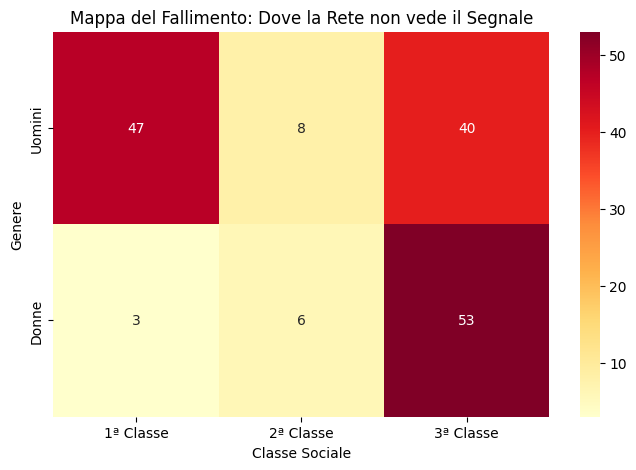

Interpretazione: I quadrati più scuri indicano dove la logica 'Donne e Bambini prima' 
si scontra con la realtà strutturale della nave (3ª classe) o con la scelta individuale (1ª classe).


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creiamo una matrice con i tuoi dati
error_data = [[47, 8, 40], [3, 6, 53]] # [Uomini p1,p2,p3], [Donne p1,p2,p3]

plt.figure(figsize=(8, 5))
sns.heatmap(error_data, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['1ª Classe', '2ª Classe', '3ª Classe'],
            yticklabels=['Uomini', 'Donne'])

plt.title('Mappa del Fallimento: Dove la Rete non vede il Segnale')
plt.xlabel('Classe Sociale')
plt.ylabel('Genere')
plt.show()

print("Interpretazione: I quadrati più scuri indicano dove la logica 'Donne e Bambini prima' \n"
      "si scontra con la realtà strutturale della nave (3ª classe) o con la scelta individuale (1ª classe).")